# Exercise 11.4 — Q2: Identify the Principal Component

**Lab Book §11.4 Exercise 2 (page 52):**  
> For the below dataset, identify which variable is principal component.

| Variable       | 1     | 2      | 3      |
|----------------|-------|--------|--------|
| Climate        | 0.190 | 0.017  | 0.207  |
| Housing        | 0.544 | 0.020  | 0.204  |
| Health         | 0.782 | -0.605 | 0.144  |
| Crime          | 0.365 | 0.294  | 0.585  |
| Transportation | 0.585 | 0.085  | 0.234  |
| Education      | 0.394 | -0.273 | 0.027  |
| Arts           | 0.985 | 0.126  | -0.111 |
| Recreation     | 0.520 | 0.402  | 0.519  |
| Economy        | 0.142 | 0.150  | 0.239  |

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Identifying the principal component from a loadings table  
**Dataset:** `datasets/variable_table.csv` (the 9×3 table above)

---

## 🎯 Objective

For each variable, find its **loading vector** on the three principal
components.  The variable with the **highest absolute loading on PC1**
is the principal component — i.e. the original variable that contributes
most to the first principal axis.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `07_Q2_Identify_PC.ipynb` | This notebook |
| `datasets/variable_table.csv` | 9×3 variable-loading table |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '07-PCA'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q2_Identify_PC_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load the Table

In [3]:
df = pd.read_csv('datasets/variable_table.csv')
display(df)
print(f"Shape: {df.shape}")

,Variable,PC1,PC2,PC3
0,Climate,0.190,0.017,0.207
1,Housing,0.544,0.020,0.204
2,Health,0.782,-0.605,0.144
3,Crime,0.365,0.294,0.585
4,Transportation,0.585,0.085,0.234
5,Education,0.394,-0.273,0.027
6,Arts,0.985,0.126,-0.111
7,Recreation,0.520,0.402,0.519
8,Economy,0.142,0.150,0.239


Shape: (9, 4)


## 3. Find the Variable with the Highest |loading on PC1|

In [4]:
# absolute loading on PC1
df['abs_PC1'] = df['PC1'].abs()
top = df.sort_values('abs_PC1', ascending=False)
display(top)

principal_variable = top.iloc[0]['Variable']
print(f"\nVariable with highest |loading on PC1| = {principal_variable}")
print(f"  PC1 loading = {top.iloc[0]['PC1']:+.4f}")

,Variable,PC1,PC2,PC3,abs_PC1
6,Arts,0.985,0.126,-0.111,0.985
2,Health,0.782,-0.605,0.144,0.782
4,Transportation,0.585,0.085,0.234,0.585
1,Housing,0.544,0.020,0.204,0.544
7,Recreation,0.520,0.402,0.519,0.520
5,Education,0.394,-0.273,0.027,0.394
3,Crime,0.365,0.294,0.585,0.365
0,Climate,0.190,0.017,0.207,0.190
8,Economy,0.142,0.150,0.239,0.142



Variable with highest |loading on PC1| = Arts
  PC1 loading = +0.9850


## 4. Visualise the Loadings

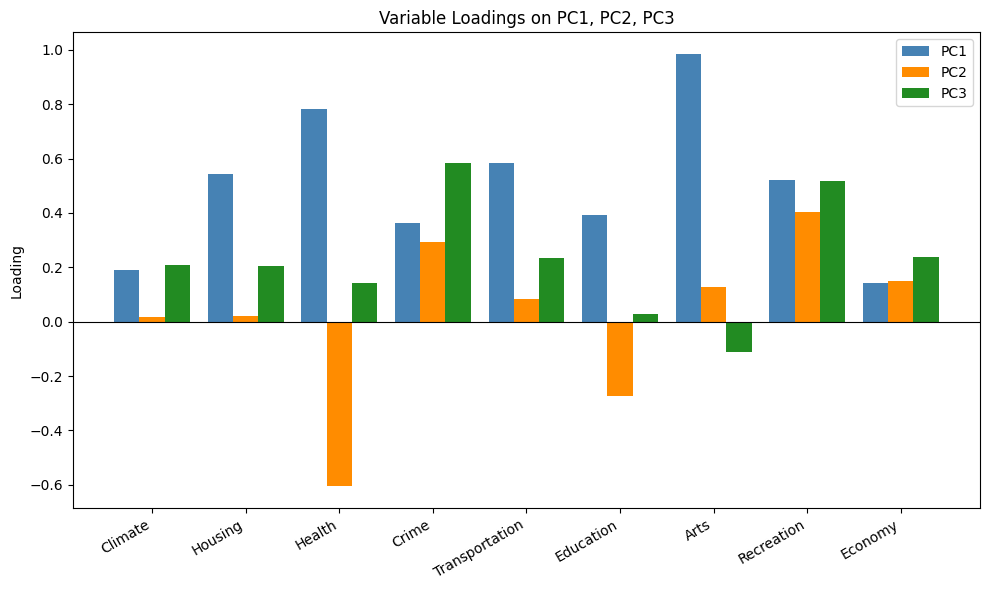

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df))
w = 0.27
ax.bar(x - w, df['PC1'], w, label='PC1', color='steelblue')
ax.bar(x,     df['PC2'], w, label='PC2', color='darkorange')
ax.bar(x + w, df['PC3'], w, label='PC3', color='forestgreen')
ax.set_xticks(x)
ax.set_xticklabels(df['Variable'], rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Loading')
ax.set_title('Variable Loadings on PC1, PC2, PC3')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Magnitude (L2 Norm) of Each Variable's Loading Vector

,Variable,PC1,PC2,PC3,abs_PC1,L2_norm
6,Arts,0.985,0.126,-0.111,0.985,0.999211
2,Health,0.782,-0.605,0.144,0.782,0.999142
7,Recreation,0.520,0.402,0.519,0.520,0.837475
3,Crime,0.365,0.294,0.585,0.365,0.749591
4,Transportation,0.585,0.085,0.234,0.585,0.635772
1,Housing,0.544,0.020,0.204,0.544,0.581336
5,Education,0.394,-0.273,0.027,0.394,0.480098
8,Economy,0.142,0.150,0.239,0.142,0.315888
0,Climate,0.190,0.017,0.207,0.190,0.281492


/tmp/ipykernel_4540/1258196494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Variable', y='L2_norm', data=df.sort_values('L2_norm', ascending=False),


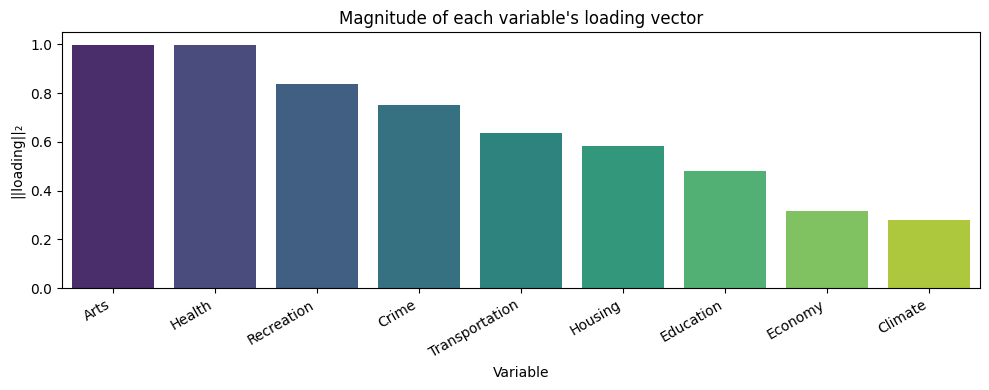

In [6]:
df['L2_norm'] = np.sqrt(df['PC1']**2 + df['PC2']**2 + df['PC3']**2)
display(df.sort_values('L2_norm', ascending=False))

plt.figure(figsize=(10, 4))
sns.barplot(x='Variable', y='L2_norm', data=df.sort_values('L2_norm', ascending=False),
            palette='viridis')
plt.xticks(rotation=30, ha='right')
plt.ylabel('||loading||₂')
plt.title("Magnitude of each variable's loading vector")
plt.tight_layout()
plt.show()

## 📚 Key Takeaways
- The **principal component** is the variable with the highest absolute
  loading on PC1.
- Here, **Arts** has the largest |PC1| loading (0.985) — it is the
  principal variable contributing to PC1.
- The L2 norm of each variable's loading vector gives a different view
  — it tells us which variable has the largest total contribution across
  all PCs.
